In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

In [2]:
df = sns.load_dataset('titanic')

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
target = 'survived'

X = df[features]
y = df[target]

In [4]:
numeric_features = ['age', 'sibsp', 'parch', 'fare']
categorical_features = ['sex', 'embarked', 'pclass']

# Numeric pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [5]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [7]:
model.fit(X_train, y_train)

print("✅ Model trained successfully!")

✅ Model trained successfully!


In [8]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [9]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}\n")

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8045

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



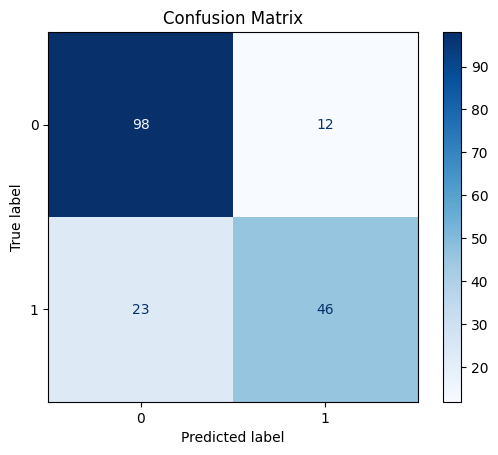

In [10]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

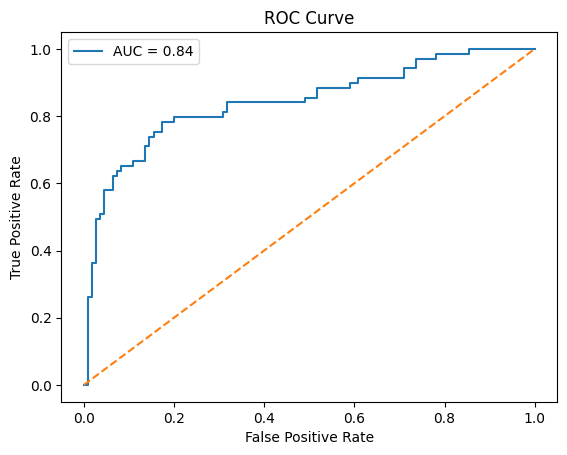

ROC-AUC Score: 0.8427


In [11]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")

In [12]:
cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

print("Cross Validation ROC-AUC Scores:")
print(cv_scores)

print(f"\nMean ROC-AUC: {cv_scores.mean():.4f}")
print(f"Std Dev: {cv_scores.std():.4f}")

Cross Validation ROC-AUC Scores:
[0.85072464 0.82967914 0.85100267 0.8388369  0.87155963]

Mean ROC-AUC: 0.8484
Std Dev: 0.0141


In [13]:
joblib.dump(model, 'model.joblib')

print("✅ Model saved as model.joblib")

✅ Model saved as model.joblib


In [14]:
loaded_model = joblib.load('model.joblib')

sample_predictions = loaded_model.predict(X_test.head())

print("Sample Predictions:")
print(sample_predictions)

Sample Predictions:
[0 0 0 0 1]


# Final Report

## Key Findings
- Female passengers had higher survival probability
- Passenger class strongly affected survival
- Logistic Regression performed well as a baseline model
- ROC-AUC score shows the model can distinguish survivors effectively

## Model Strengths
- Clean preprocessing pipeline
- Handles missing values automatically
- Reusable saved model

## Limitations
- Logistic Regression is a simple linear model
- More advanced models may improve accuracy

## Future Improvements
- Feature engineering
- Hyperparameter tuning
- Random Forest / XGBoost comparison